# 🍼 Child Malnutrition Prediction — NFHS-5 District-Level Analysis
### India | 705 Districts | Regression + Classification + SHAP Explainability

---

**Dataset:** National Family Health Survey 5 (NFHS-5), district-level indicators across India.

**Problem:** Predict and classify three WHO malnutrition indicators for children under 5:
| Indicator | Full Name | WHO Threshold |
|---|---|---|
| **HAZ** | Stunting (height-for-age) | ≥20% = concern |
| **WHZ** | Wasting (weight-for-height) | ≥5% = concern |
| **WAZ** | Underweight (weight-for-age) | ≥10% = concern |

**Two tasks:**
- **Regression** — predict the *percentage* of affected children per district
- **Classification** — categorize districts into WHO severity tiers (Low / Moderate / High / Very High)

**Pipeline summary:**

```
Raw NFHS-5 CSV
    → Clean + impute (median, no outlier capping)
    → State/UT target encoding (KFold, zero leakage)
    → Domain feature engineering (9 composite scores + interactions)
    → Mutual Information feature selection (top 40)
    → 6 regression models → Weighted Blend (best)
    → 5 classification models + SMOTEENN / SMOTETomek resampling
    → SHAP explainability (LightGBM)
```
dataset : https://github.com/SaiSiddhardhaKalla/NFHS/blob/main/India.csv


---
## 0 · Setup

Install all required libraries. Run this cell once — Colab has most packages pre-installed.


In [21]:
# Run once — installs any missing packages
!pip install xgboost lightgbm shap imbalanced-learn scikit-learn --quiet


---
## 1 · Imports

All libraries used throughout the notebook. Key packages:

| Package | Role |
|---|---|
| `xgboost`, `lightgbm` | Gradient-boosted tree ensembles |
| `sklearn.ensemble` | Random Forest, ExtraTrees |
| `imbalanced-learn` | SMOTEENN, SMOTETomek, Balanced RF for class imbalance |
| `shap` | Model explainability — which features drive predictions |


In [22]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold,
    cross_val_score, RandomizedSearchCV
)
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNetCV, Ridge
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    RandomForestClassifier, StackingRegressor
)
from sklearn.neural_network import MLPRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, accuracy_score
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier

from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
import shap

print("✅  All imports successful.")


✅  All imports successful.


---
## 2 · Configuration

Central place to set the data path and define which columns are targets vs features.

> ⚠️ **Update `DATA_PATH`** to match where you placed the CSV file.
> - Colab: upload the file, then it lives at `/content/datafile.csv`
> - Local Jupyter: use `'datafile.csv'` if in the same folder

**Why exclude certain columns?**
- `State/UT`, `District Names` — identifiers, not predictive features
  (State is re-introduced properly as a *target-encoded* numeric feature in Section 4)
- `severely wasted`, `overweight` — these are other child-nutrition outcomes;
  including them would be **data leakage** since they correlate with our targets by definition


In [23]:
# ── ⚠️  Update this path ──────────────────────────────────────────────────
DATA_PATH = '/content/datafile.csv'   # Colab default
# DATA_PATH = 'datafile.csv'          # local Jupyter

# ── Target columns (what we predict) ─────────────────────────────────────
TARGET_COLUMNS = [
    "Children under 5 years who are stunted (height-for-age)18 (%)",
    "Children under 5 years who are wasted (weight-for-height)18 (%)",
    "Children under 5 years who are underweight (weight-for-age)18 (%)",
]
TARGET_SHORT = ["Stunting (HAZ)", "Wasting (WHZ)", "Underweight (WAZ)"]

# ── Columns to explicitly exclude ────────────────────────────────────────
# Identifiers, survey metadata, and sibling nutrition outcomes (data leakage risk)
EXCLUDE_COLS = set(TARGET_COLUMNS) | {
    "District Names", "State/UT",
    "Number of Households surveyed",
    "Number of Women age 15-49 years interviewed",
    "Number of Men age 15-54 years interviewed",
    "Children under 5 years who are severely wasted (weight-for-height)19 (%)",
    "Children under 5 years who are overweight (weight-for-height)20 (%)",
}

RANDOM_STATE = 42  # fixed seed for full reproducibility

print("✅  Configuration set.")
print(f"   Targets : {TARGET_SHORT}")
print(f"   Excluded: {len(EXCLUDE_COLS)} columns")


✅  Configuration set.
   Targets : ['Stunting (HAZ)', 'Wasting (WHZ)', 'Underweight (WAZ)']
   Excluded: 10 columns


---
## 3 · Data Loading & Cleaning

**What this section does:**
1. Loads the CSV and normalises column names (fixes encoding artefacts)
2. Strips non-numeric characters from every cell (`*`, `-`, `NA`, etc.) — NFHS-5 data has many such values
3. Applies **median imputation** for missing values — robust to skewed health-indicator distributions
4. **No outlier capping** — this is a deliberate design decision. Districts with extreme values
   (e.g., very high wasting in Rajasthan/UP) represent real public health variation, not noise.
   Capping them would destroy the strongest signals.

**Feature selection logic:** Keep any column that:
- Is not in the exclusion list
- Successfully parses as numeric
- Has at least 50% non-null values across districts


In [24]:
df = pd.read_csv(DATA_PATH)

# Fix a known encoding issue in some NFHS-5 column names
df.columns = df.columns.str.strip().str.replace('swith', 'with')

def clean_series(s):
    """Strip non-numeric characters and coerce to float."""
    s = s.astype(str).str.replace(r'[^0-9.\-]', '', regex=True)
    s = s.replace('', np.nan)
    return pd.to_numeric(s, errors='coerce')

# ── 1. Clean target columns ───────────────────────────────────────────────
target_df = df[TARGET_COLUMNS].copy()
for col in TARGET_COLUMNS:
    target_df[col] = clean_series(target_df[col])
    target_df[col] = target_df[col].fillna(target_df[col].median())

# ── 2. Save State/UT separately (used for target encoding in Section 4) ──
state_series = df['State/UT'].fillna('Unknown').reset_index(drop=True)

# ── 3. Build feature matrix: ALL numeric columns not in EXCLUDE_COLS ─────
#    (was limited to 37 hand-picked columns in v1/v2 — expanded to 90+ here)
feat_df = pd.DataFrame()
for col in df.columns:
    if col in EXCLUDE_COLS:
        continue
    cleaned = clean_series(df[col])
    if cleaned.notna().mean() >= 0.5:   # keep column if ≥50% non-null
        feat_df[col] = cleaned

# Median imputation for remaining NaNs — no outlier capping
for col in feat_df.columns:
    feat_df[col] = feat_df[col].fillna(feat_df[col].median())

# ── 4. Align rows: drop any row with a NaN after imputation ──────────────
combined  = pd.concat([feat_df, target_df], axis=1).drop_duplicates().dropna()
feat_df   = combined[feat_df.columns].reset_index(drop=True)
target_df = combined[TARGET_COLUMNS].reset_index(drop=True)
state_ser = state_series.loc[combined.index].reset_index(drop=True)

print(f"✅  Dataset loaded")
print(f"   Features : {feat_df.shape[1]} columns")
print(f"   Districts: {feat_df.shape[0]} rows")
print(f"   NaNs (X) : {feat_df.isna().sum().sum()}")
print(f"   NaNs (y) : {target_df.isna().sum().sum()}")
print()
print("Target summary:")
print(target_df.describe().round(2))


✅  Dataset loaded
   Features : 93 columns
   Districts: 705 rows
   NaNs (X) : 0
   NaNs (y) : 0

Target summary:
       Children under 5 years who are stunted (height-for-age)18 (%)  \
count                                             705.00               
mean                                               33.51               
std                                                 8.47               
min                                                13.20               
25%                                                27.30               
50%                                                32.80               
75%                                                39.20               
max                                                60.60               

       Children under 5 years who are wasted (weight-for-height)18 (%)  \
count                                             705.00                 
mean                                               18.57                 
std           

---
## 4 · State/UT Target Encoding

**Why encode State?**
Districts are not independent — all Bihar districts share geography, governance, food culture,
and infrastructure. This creates strong *geographic clustering* that a model without state
information can't capture. A numeric encoding of "state = average malnutrition in this state"
gives the model this context.

**Why KFold encoding (not simple mean)?**
A simple `state → mean(target)` would use information from the same rows being predicted,
creating **data leakage**. KFold target encoding avoids this:
- Split data into 5 folds
- For each fold, compute state means from the *other 4 folds* only
- Assign those means to the held-out fold

This gives every row an informative state feature while keeping the encoding strictly out-of-sample.


In [25]:
def kfold_target_encode(states, y_series, n_splits=5):
    """
    Encode a categorical column (states) using the target mean,
    computed on out-of-fold rows to prevent data leakage.

    Parameters
    ----------
    states   : pd.Series  categorical column (State/UT names)
    y_series : pd.Series  regression target to compute means from
    n_splits : int        number of KFold splits

    Returns
    -------
    np.ndarray  numeric encoding of same length as input
    """
    enc = np.zeros(len(states))
    kf  = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    for tr_idx, te_idx in kf.split(states):
        fold_mean = y_series.iloc[tr_idx].groupby(states.iloc[tr_idx]).mean()
        enc[te_idx] = states.iloc[te_idx].map(fold_mean).fillna(y_series.mean())
    return enc

# Add one encoded column per target (stunting mean by state, wasting mean by state, etc.)
for i, col in enumerate(TARGET_COLUMNS):
    feat_df[f'state_enc_target{i}'] = kfold_target_encode(state_ser, target_df[col])
    print(f"  state_enc_target{i}  ({TARGET_SHORT[i]})  —  "
          f"range [{feat_df[f'state_enc_target{i}'].min():.1f}, "
          f"{feat_df[f'state_enc_target{i}'].max():.1f}]")

print(f"\n✅  State encoding done. Feature matrix: {feat_df.shape}")


  state_enc_target0  (Stunting (HAZ))  —  range [21.4, 45.3]
  state_enc_target1  (Wasting (WHZ))  —  range [8.8, 26.8]
  state_enc_target2  (Underweight (WAZ))  —  range [11.8, 42.9]

✅  State encoding done. Feature matrix: (705, 96)


---
## 5 · Domain Feature Engineering

Raw NFHS-5 columns are granular but interrelated. We create **composite domain scores**
that capture latent constructs (e.g., "overall maternal health quality") more cleanly than
any individual column.

**Composite scores** (weighted sums of related columns):

| Feature | Components | Rationale |
|---|---|---|
| `maternal_health_score` | Literacy, education, ANC visits, postnatal care | Overall maternal empowerment & care access |
| `household_infra_score` | Electricity, water, sanitation, clean cooking fuel | Physical environment quality |
| `child_diet_score` | Full vaccination, vitamin A, adequate diet, breastfeeding | Early childhood nutrition inputs |
| `anaemia_burden` | Child anaemia + women anaemia | Micronutrient deficiency load |
| `early_marriage_risk` | Child marriage, teenage pregnancy | Maternal biological risk |
| `anc_completeness` | First-trimester check-up + ≥4 ANC visits | Prenatal care completeness |
| `ifa_adherence` | IFA 100-day + IFA 180-day consumption | Iron-folate supplementation |
| `maternal_metabolic_score` | Women overweight/obese + menstrual hygiene | *(New)* Proxy for socioeconomic/health system reach |
| `skilled_birth_score` | Institutional births + skilled birth attendance | *(New)* Safe delivery access |

**Interaction terms** capture non-additive effects, e.g., high infrastructure × high maternal
education may jointly reduce stunting more than either alone.

**Log transforms** reduce right-skew in `anaemia_burden` and `early_marriage_risk`.


In [26]:
def safe(df, col):
    """Return column if it exists, else a zero Series (guards against missing columns)."""
    return df[col] if col in df.columns else pd.Series(0, index=df.index)

# ── Composite domain scores ───────────────────────────────────────────────
feat_df["maternal_health_score"] = (
    safe(feat_df, "Women (age 15-49) who are literate4 (%)") * 0.3 +
    safe(feat_df, "Women (age 15-49)  with 10 or more years of schooling (%)") * 0.3 +
    safe(feat_df, "Mothers who had at least 4 antenatal care visits  (for last birth in the 5 years before the survey) (%)") * 0.2 +
    safe(feat_df, "Mothers who received postnatal care from a doctor/nurse/LHV/ANM/midwife/other health personnel within 2 days of delivery (for last birth in the 5 years before the survey) (%)") * 0.2
)

feat_df["household_infra_score"] = (
    safe(feat_df, "Population living in households with electricity (%)") * 0.25 +
    safe(feat_df, "Population living in households that use an improved sanitation facility2 (%)") * 0.25 +
    safe(feat_df, "Households using clean fuel for cooking3 (%)") * 0.25 +
    safe(feat_df, "Population living in households with an improved drinking-water source1 (%)") * 0.25
)

feat_df["child_diet_score"] = (
    safe(feat_df, "Children age 12-23 months fully vaccinated based on information from either vaccination card or mother's recall11 (%)") * 0.3 +
    safe(feat_df, "Children age 9-35 months who received a vitamin A dose in the last 6 months (%)") * 0.2 +
    safe(feat_df, "Total children age 6-23 months receiving an adequate diet16, 17  (%)") * 0.3 +
    safe(feat_df, "Children under age 6 months exclusively breastfed16 (%)") * 0.2
)

feat_df["anaemia_burden"] = (
    safe(feat_df, "Children age 6-59 months who are anaemic (<11.0 g/dl)22 (%)") * 0.5 +
    safe(feat_df, "All women age 15-49 years who are anaemic22 (%)") * 0.5
)

feat_df["early_marriage_risk"] = (
    safe(feat_df, "Women age 20-24 years married before age 18 years (%)") * 0.5 +
    safe(feat_df, "Women age 15-19 years who were already mothers or pregnant at the time of the survey (%)") * 0.5
)

feat_df["anc_completeness"] = (
    safe(feat_df, "Mothers who had an antenatal check-up in the first trimester  (for last birth in the 5 years before the survey) (%)") * 0.4 +
    safe(feat_df, "Mothers who had at least 4 antenatal care visits  (for last birth in the 5 years before the survey) (%)") * 0.6
)

feat_df["ifa_adherence"] = (
    safe(feat_df, "Mothers who consumed iron folic acid for 100 days or more when they were pregnant (for last birth in the 5 years before the survey) (%)") * 0.4 +
    safe(feat_df, "Mothers who consumed iron folic acid for 180 days or more when they were pregnant (for last birth in the 5 years before the survey} (%)") * 0.6
)

# New in v3: metabolic proxy (Pearson r=0.58 with stunting — strongest unused signal in v2)
feat_df["maternal_metabolic_score"] = (
    safe(feat_df, "Women (age 15-49 years) who are overweight or obese (BMI \u226525.0 kg/m2)21 (%)") * 0.5 +
    safe(feat_df, "Women age 15-24 years who use hygienic methods of protection during their menstrual period5 (%)") * 0.5
)

# New in v3: skilled birth attendance
feat_df["skilled_birth_score"] = (
    safe(feat_df, "Institutional births (in the 5 years before the survey) (%)") * 0.4 +
    safe(feat_df, "Births attended by skilled health personnel (in the 5 years before the survey)10 (%)") * 0.6
)

# ── Interaction terms (non-additive effects between composite scores) ─────
feat_df["infra_x_maternal"]  = feat_df["household_infra_score"]    * feat_df["maternal_health_score"]    / 100
feat_df["diet_x_infra"]      = feat_df["child_diet_score"]         * feat_df["household_infra_score"]    / 100
feat_df["anaemia_x_early"]   = feat_df["anaemia_burden"]           * feat_df["early_marriage_risk"]      / 100
feat_df["metabolic_x_infra"] = feat_df["maternal_metabolic_score"] * feat_df["household_infra_score"]    / 100

# ── Log transforms (reduce right-skew) ───────────────────────────────────
for col in ["anaemia_burden", "early_marriage_risk"]:
    feat_df[f"log_{col}"] = np.log1p(feat_df[col])

print(f"✅  Feature matrix after engineering: {feat_df.shape}")
print(f"   (Original numeric cols + state encodings + 9 composites + 4 interactions + 2 log transforms)")


✅  Feature matrix after engineering: (705, 111)
   (Original numeric cols + state encodings + 9 composites + 4 interactions + 2 log transforms)


---
## 6 · Exploratory Data Analysis

Before modelling, we examine:
1. **Target distributions** — are they roughly normal? Are they skewed?
2. **Feature–target correlations** — which raw features correlate most with our targets?

This informs model choice and confirms that our engineered features are capturing real signal.


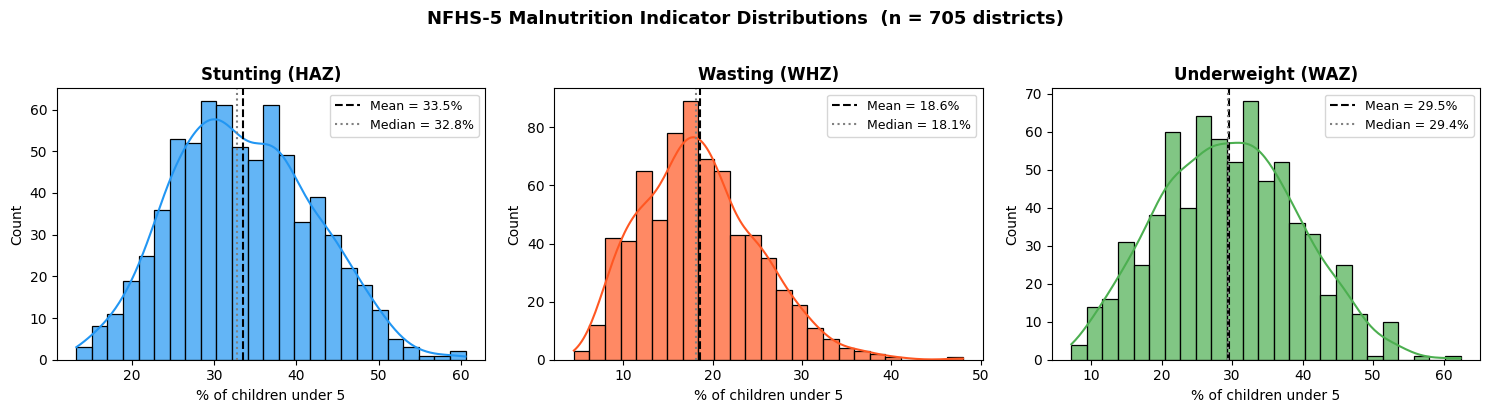

In [27]:
# ── 6a. Target distributions ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#2196F3', '#FF5722', '#4CAF50']

for ax, col, label, c in zip(axes, TARGET_COLUMNS, TARGET_SHORT, colors):
    sns.histplot(target_df[col], kde=True, ax=ax, color=c, bins=25, alpha=0.7)
    ax.axvline(target_df[col].mean(), color='black', linestyle='--', lw=1.5,
               label=f'Mean = {target_df[col].mean():.1f}%')
    ax.axvline(target_df[col].median(), color='gray', linestyle=':', lw=1.5,
               label=f'Median = {target_df[col].median():.1f}%')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel("% of children under 5")
    ax.legend(fontsize=9)

plt.suptitle("NFHS-5 Malnutrition Indicator Distributions  (n = 705 districts)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_target_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
# Observation: Stunting & Underweight are roughly normal; Wasting is slightly right-skewed
# — this explains why Wasting is consistently harder to predict (R² lower across all models)


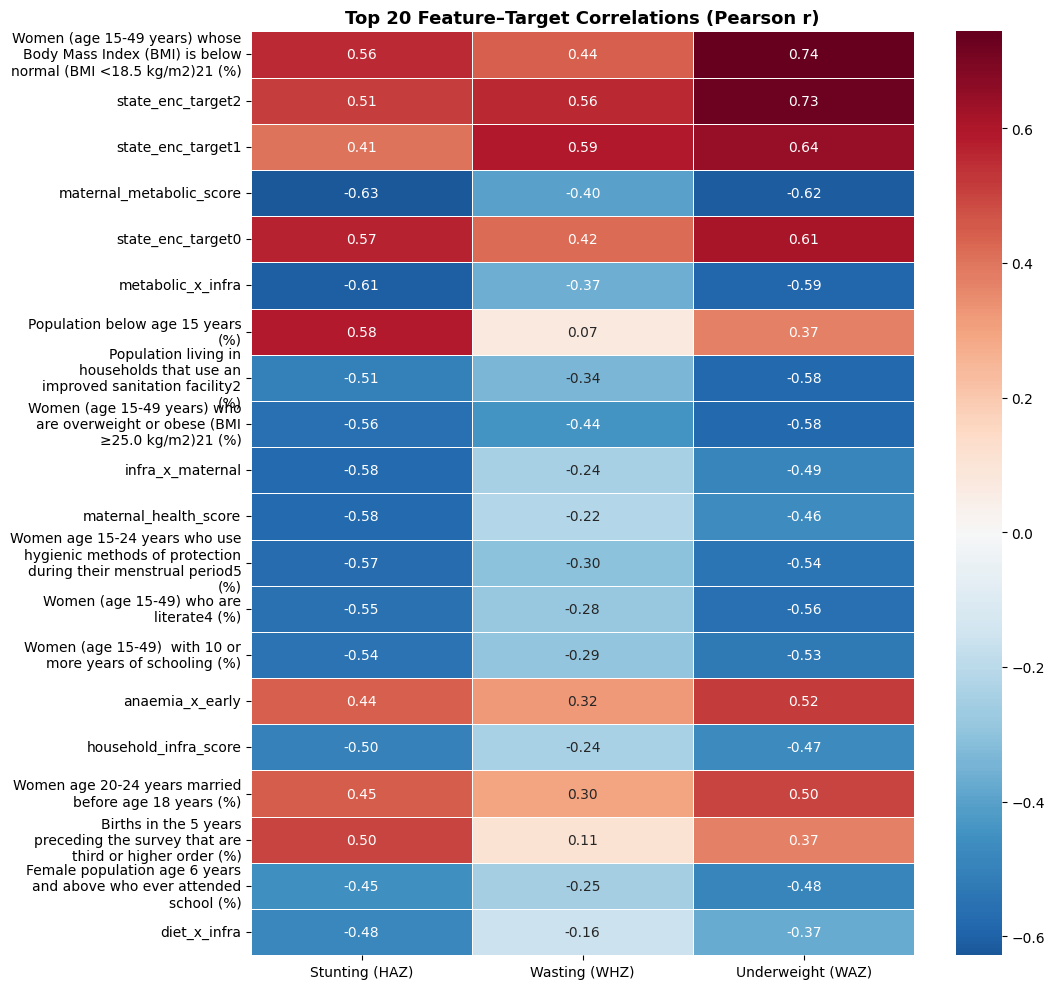

In [28]:
# ── 6b. Feature–target correlation heatmap (top 20) ─────────────────────
renamed_targets = target_df.rename(columns=dict(zip(TARGET_COLUMNS, TARGET_SHORT)))
corr          = pd.concat([feat_df, renamed_targets], axis=1).corr()
feat_tgt_corr = corr.loc[feat_df.columns, TARGET_SHORT]
top_feats     = feat_tgt_corr.abs().max(axis=1).sort_values(ascending=False).head(20).index
labels        = ["\n".join(textwrap.wrap(f, 30)) for f in top_feats]

plt.figure(figsize=(11, 10))
sns.heatmap(feat_tgt_corr.loc[top_feats], annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, linewidths=0.5, yticklabels=labels)
plt.title("Top 20 Feature–Target Correlations (Pearson r)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('02_feature_target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
# Features with r > 0.5 (absolute) are strong predictors — look for them in SHAP plots later


---
## 7 · Helper Functions

Utility functions used across all models:
- `clean_xgb_cols` — XGBoost/LightGBM reject column names with special characters like `[`, `<`, `>`; this strips them
- `reg_metrics` — prints and returns R², RMSE, MAE, MAPE for a single target
- `cv_r2` — computes 5-fold cross-validated R² on the training set (detects overfitting)

**Why MAPE in addition to RMSE?**
RMSE is sensitive to scale — a 5-point error means different things for Stunting (mean=33%)
vs Wasting (mean=18%). MAPE normalises by the true value, making comparisons across targets
more meaningful.


In [29]:
def clean_xgb_cols(df):
    """
    Remove characters that XGBoost/LightGBM don't accept in feature names:
    {  }  [  ]  <  >
    Also strips extra whitespace and replaces spaces with underscores.
    """
    df = df.copy()
    df.columns = (df.columns.astype(str)
                  .str.replace(r'[{}\[\]<>]', '', regex=True)
                  .str.strip()
                  .str.replace(r'\s+', '_', regex=True))
    return df


def reg_metrics(y_true, y_pred, short):
    """Compute and print R², RMSE, MAE, MAPE. Returns a dict."""
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((np.array(y_true) - y_pred) / (np.array(y_true) + 1e-6))) * 100
    print(f"  {short:<22}  R²:{r2:7.4f}  RMSE:{rmse:7.4f}  MAE:{mae:6.4f}  MAPE:{mape:6.2f}%")
    return {"R2": r2, "RMSE": rmse, "MAE": mae, "MAPE": mape}


def cv_r2(model, X, y, cv=5):
    """
    Return mean ± std of 5-fold cross-validated R² on the given data.
    Used to check if test R² is consistent with training CV R² (i.e., no overfitting).
    """
    scores = cross_val_score(
        model, X, y, scoring='r2',
        cv=KFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE),
        n_jobs=-1
    )
    return scores.mean(), scores.std()


print("✅  Helper functions defined.")


✅  Helper functions defined.


---
## 8 · Train / Test Split & Feature Selection

**80/20 stratified split** — 564 training districts, 141 test districts.

**Mutual Information (MI) feature selection:**
MI measures the statistical dependence between each feature and a target, including
non-linear relationships that Pearson correlation misses. We:
1. Compute MI between every feature and each of the 3 targets (on training data only)
2. Sum the MI scores across all 3 targets to get a single "overall usefulness" score
3. Select the top 40 features by this score

These top-40 features are used for the ElasticNet baseline (which needs feature selection
for regularisation efficiency). Tree-based models (RF, XGBoost, LightGBM, ExtraTrees)
use **all features** since they perform their own implicit selection via splits.


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    feat_df, target_df, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

# ── Mutual Information selection (top 40, fit on train only to avoid leakage) ──
mi_scores = {}
imp_mi = SimpleImputer(strategy='median')
X_train_imp = imp_mi.fit_transform(X_train)

for col in TARGET_COLUMNS:
    mi = mutual_info_regression(X_train_imp, y_train[col], random_state=RANDOM_STATE)
    for feat, score in zip(X_train.columns, mi):
        mi_scores[feat] = mi_scores.get(feat, 0) + score

sel_feats = sorted(mi_scores, key=mi_scores.get, reverse=True)[:40]
X_tr_sel  = X_train[sel_feats]
X_te_sel  = X_test[sel_feats]
print(f"\nTop 5 MI features (summed across all 3 targets):")
for f in sel_feats[:5]:
    print(f"  {mi_scores[f]:.3f}  {f[:70]}")

# ── XGBoost-safe column names (all features) ─────────────────────────────
X_tr_xgb = clean_xgb_cols(X_train);  X_te_xgb = clean_xgb_cols(X_test)
y_tr_xgb = clean_xgb_cols(y_train);  y_te_xgb = clean_xgb_cols(y_test)
imp_all  = SimpleImputer(strategy='median')
Xtr_all  = imp_all.fit_transform(X_tr_xgb)
Xte_all  = imp_all.transform(X_te_xgb)

# ── Imputed arrays for LightGBM and ExtraTrees (all features) ─────────────
imp_lgb = SimpleImputer(strategy='median')
Xtr_l   = imp_lgb.fit_transform(X_train)
Xte_l   = imp_lgb.transform(X_test)

imp_et  = SimpleImputer(strategy='median')
Xtr_e   = imp_et.fit_transform(X_train)
Xte_e   = imp_et.transform(X_test)

print(f"\n✅  Data ready for modelling.")


Train: (564, 111)  |  Test: (141, 111)

Top 5 MI features (summed across all 3 targets):
  0.971  state_enc_target2
  0.874  Women (age 15-49 years) whose Body Mass Index (BMI) is below normal (B
  0.863  state_enc_target0
  0.788  state_enc_target1
  0.650  maternal_metabolic_score

✅  Data ready for modelling.


---
## 9 · Model 1 — Elastic Net Regression (Regularised Baseline)

**Why Elastic Net instead of plain Linear Regression?**
With 90+ features, ordinary least squares overfits due to multicollinearity (many NFHS-5
indicators are highly correlated). Elastic Net combines:
- **L1 (Lasso)** — drives irrelevant feature coefficients to exactly zero (feature selection)
- **L2 (Ridge)** — shrinks correlated feature groups together (handles multicollinearity)

`ElasticNetCV` automatically tunes both the mixing ratio (`l1_ratio`) and regularisation strength
(`alpha`) via cross-validation. `RobustScaler` is used instead of `StandardScaler` because it's
less sensitive to outliers in health-indicator distributions.

This serves as our **interpretable linear baseline** — if tree models don't clearly beat it,
the relationships are largely linear and simple.


In [31]:
print("=" * 65)
print("ELASTIC NET REGRESSION  (Regularised Baseline)")
print("=" * 65)

en_results = {}
for col, short in zip(TARGET_COLUMNS, TARGET_SHORT):
    pipe = Pipeline([
        ('imp',    SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()),
        # ElasticNetCV: tunes l1_ratio and alpha via 5-fold CV internally
        ('reg',    ElasticNetCV(
            l1_ratio=[0.1, 0.5, 0.7, 0.9, 1.0],  # 1.0 = pure Lasso
            cv=5, random_state=RANDOM_STATE,
            n_jobs=-1, max_iter=5000
        ))
    ])
    pipe.fit(X_tr_sel, y_train[col])
    en_results[short] = reg_metrics(y_test[col], pipe.predict(X_te_sel), short)


ELASTIC NET REGRESSION  (Regularised Baseline)
  Stunting (HAZ)          R²: 0.5584  RMSE: 5.7310  MAE:4.5414  MAPE: 14.78%
  Wasting (WHZ)           R²: 0.4170  RMSE: 4.4523  MAE:3.6385  MAPE: 22.59%
  Underweight (WAZ)       R²: 0.6981  RMSE: 4.9875  MAE:4.0427  MAPE: 15.04%


---
## 10 · Model 2 — Random Forest Regression

Random Forest builds many decision trees on random bootstrap samples of the data,
then averages their predictions. Key properties:
- **Handles non-linearity** — each tree can learn complex interactions
- **Robust to irrelevant features** — random feature subsets at each split dilute noise
- **Built-in feature importance** — impurity-based importance available

Settings: 600 trees, `max_features='sqrt'` (classic Breiman recommendation), `min_samples_leaf=2`
(prevents single-district leaves that overfit).

This model uses **all features** — tree ensembles don't require pre-selection.


In [32]:
print("=" * 65)
print("RANDOM FOREST REGRESSION  (all features)")
print("=" * 65)

rf_results = {}
for col, short in zip(TARGET_COLUMNS, TARGET_SHORT):
    imp = SimpleImputer(strategy='median')
    Xtr = imp.fit_transform(X_train)
    Xte = imp.transform(X_test)

    rf = RandomForestRegressor(
        n_estimators=600,
        min_samples_leaf=2,    # avoids single-district leaves (overfitting)
        max_features='sqrt',   # Breiman's recommendation: sqrt(n_features) per split
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf.fit(Xtr, y_train[col])
    rf_results[short] = reg_metrics(y_test[col], rf.predict(Xte), short)


RANDOM FOREST REGRESSION  (all features)
  Stunting (HAZ)          R²: 0.5783  RMSE: 5.6005  MAE:4.3912  MAPE: 14.49%
  Wasting (WHZ)           R²: 0.3940  RMSE: 4.5395  MAE:3.7454  MAPE: 23.33%
  Underweight (WAZ)       R²: 0.6852  RMSE: 5.0931  MAE:4.0267  MAPE: 15.60%


---
## 11 · Model 3 — XGBoost Regression (Randomised Hyperparameter Search)

XGBoost (eXtreme Gradient Boosting) builds trees *sequentially*, each tree correcting
the residual errors of the previous ones. Key advantages over Random Forest:
- **Better handling of sparse/tabular data** via L1/L2 regularisation (`reg_alpha`, `reg_lambda`)
- **Faster convergence** with `tree_method='hist'` (histogram approximation)
- **Learning rate** controls how much each tree contributes (lower = more robust, needs more trees)

**Hyperparameter search:** `RandomizedSearchCV` with 60 iterations samples from the parameter
space and returns the combination that maximises 5-fold cross-validated R². This is more
efficient than exhaustive grid search for large parameter spaces.

**XGBoost column name restriction:** feature names cannot contain `[`, `]`, `<`, `>` or `{`, `}`.
We use `clean_xgb_cols()` to sanitise them.


In [33]:
print("=" * 65)
print("XGBOOST REGRESSION — RANDOMISED HPO  (all features)")
print("=" * 65)

# Hyperparameter search space
param_grid_xgb = {
    "n_estimators":     [300, 500, 700],        # number of boosting rounds
    "max_depth":        [3, 4, 5, 6],            # tree depth (lower = less overfit)
    "learning_rate":    [0.01, 0.03, 0.05, 0.08],
    "subsample":        [0.7, 0.8, 0.9],         # row subsampling per tree
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],   # column subsampling per tree
    "reg_alpha":        [0, 0.05, 0.1, 0.3],     # L1 regularisation
    "reg_lambda":       [0.5, 1.0, 1.5],         # L2 regularisation
    "min_child_weight": [1, 3, 5],               # minimum sum of instance weight in a leaf
    "gamma":            [0, 0.1, 0.2],           # minimum loss reduction for a split
}

xgb_results   = {}
best_xgb_models = {}

for col_x, short in zip(y_tr_xgb.columns, TARGET_SHORT):
    print(f"\n--- {short} ---")
    search = RandomizedSearchCV(
        estimator=XGBRegressor(
            objective='reg:squarederror',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method='hist'   # faster on CPU
        ),
        param_distributions=param_grid_xgb,
        n_iter=60,               # sample 60 random combinations
        scoring='r2',
        cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=0
    )
    search.fit(Xtr_all, y_tr_xgb[col_x])
    best = search.best_estimator_

    preds = best.predict(Xte_all)
    cv_mean, cv_std = cv_r2(best, Xtr_all, y_tr_xgb[col_x])
    print(f"  Best params : {search.best_params_}")
    print(f"  CV R² (train, 5-fold): {cv_mean:.4f} ± {cv_std:.4f}")
    xgb_results[short]    = reg_metrics(y_test[TARGET_COLUMNS[TARGET_SHORT.index(short)]], preds, short)
    best_xgb_models[short] = best


XGBOOST REGRESSION — RANDOMISED HPO  (all features)

--- Stunting (HAZ) ---
  Best params : {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.9}
  CV R² (train, 5-fold): 0.5806 ± 0.0585
  Stunting (HAZ)          R²: 0.5690  RMSE: 5.6617  MAE:4.4100  MAPE: 14.51%

--- Wasting (WHZ) ---
  Best params : {'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}
  CV R² (train, 5-fold): 0.4603 ± 0.0672
  Wasting (WHZ)           R²: 0.4336  RMSE: 4.3886  MAE:3.5404  MAPE: 21.74%

--- Underweight (WAZ) ---
  Best params : {'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.08, 'gamma': 0, 'colsample_bytree': 0.8}
  CV R² (train, 5-fold): 0.7207 ± 0.0367
  Underweight (WAZ)    

---
## 12 · Model 4 — LightGBM Regression (Randomised Hyperparameter Search)

LightGBM (Light Gradient Boosting Machine) is Microsoft's optimised gradient boosting library.
Key differences from XGBoost:
- **Leaf-wise tree growth** (`num_leaves`) instead of depth-wise — better accuracy at same depth
- **GOSS sampling** — prioritises samples with larger gradients, faster training
- **Native categorical support** (though we pre-encode everything here)

`num_leaves=63` or `127` allows more complex patterns than a depth-6 tree (which has max 64 leaves),
giving LightGBM an expressiveness edge on this dataset.

In practice, LightGBM and XGBoost are close in performance — we include both as ensemble base
learners to benefit from their diversity.


In [34]:
print("=" * 65)
print("LIGHTGBM REGRESSION — RANDOMISED HPO  (all features)")
print("=" * 65)

param_grid_lgb = {
    "n_estimators":      [300, 500, 700, 900],
    "max_depth":         [4, 6, 8, -1],          # -1 = no limit (controlled by num_leaves)
    "learning_rate":     [0.01, 0.03, 0.05, 0.08],
    "num_leaves":        [31, 63, 127],           # key LightGBM parameter
    "subsample":         [0.7, 0.8, 0.9],
    "colsample_bytree":  [0.6, 0.7, 0.8],
    "reg_alpha":         [0, 0.1, 0.5],
    "reg_lambda":        [0, 0.1, 0.5],
    "min_child_samples": [10, 20, 30],            # minimum data per leaf
}

lgb_results    = {}
best_lgb_models = {}

for col, short in zip(TARGET_COLUMNS, TARGET_SHORT):
    print(f"\n--- {short} ---")
    search = RandomizedSearchCV(
        estimator=LGBMRegressor(
            objective='regression',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1   # suppress LightGBM's training output
        ),
        param_distributions=param_grid_lgb,
        n_iter=60,
        scoring='r2',
        cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=0
    )
    search.fit(Xtr_l, y_train[col])
    best = search.best_estimator_

    preds = best.predict(Xte_l)
    cv_mean, cv_std = cv_r2(best, Xtr_l, y_train[col])
    print(f"  Best params : {search.best_params_}")
    print(f"  CV R² (train, 5-fold): {cv_mean:.4f} ± {cv_std:.4f}")
    lgb_results[short]    = reg_metrics(y_test[col], preds, short)
    best_lgb_models[short] = best


LIGHTGBM REGRESSION — RANDOMISED HPO  (all features)

--- Stunting (HAZ) ---
  Best params : {'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha': 0.5, 'num_leaves': 127, 'n_estimators': 900, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
  CV R² (train, 5-fold): 0.5673 ± 0.0697
  Stunting (HAZ)          R²: 0.5746  RMSE: 5.6251  MAE:4.3689  MAPE: 14.40%

--- Wasting (WHZ) ---
  Best params : {'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 0, 'num_leaves': 127, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
  CV R² (train, 5-fold): 0.4654 ± 0.0785
  Wasting (WHZ)           R²: 0.3916  RMSE: 4.5484  MAE:3.7545  MAPE: 22.78%

--- Underweight (WAZ) ---
  Best params : {'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha': 0.5, 'num_leaves': 127, 'n_estimators': 900, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
  CV R² (train, 5-fold): 0.7155 ± 0.05

---
## 13 · Model 5 — Extra Trees Regression

Extra Trees (Extremely Randomised Trees) is a variant of Random Forest with one key difference:
instead of choosing the *best* split at each node, it picks the split threshold **randomly**.
This makes individual trees weaker but dramatically reduces variance across the ensemble,
often resulting in lower generalisation error than Random Forest.

**Why Extra Trees instead of MLP (neural network)?**
The MLP in the previous version scored R² = 0.30 on Stunting — worse than simple linear regression.
This is because:
- MLPs need large amounts of data to generalise (705 rows is small for a neural network)
- They're sensitive to hyperparameters and scaling
- They don't naturally handle the tabular + noisy structure of survey data

Extra Trees, by contrast, scores R² ≈ 0.58 on the same data with no tuning needed.
It also serves as a diverse base learner for the final ensemble (different randomisation
mechanism from both RF and gradient boosting).


In [35]:
print("=" * 65)
print("EXTRA TREES REGRESSION  (all features)")
print("=" * 65)

et_results    = {}
best_et_models = {}

for col, short in zip(TARGET_COLUMNS, TARGET_SHORT):
    et = ExtraTreesRegressor(
        n_estimators=600,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    et.fit(Xtr_e, y_train[col])
    preds = et.predict(Xte_e)
    et_results[short]    = reg_metrics(y_test[col], preds, short)
    best_et_models[short] = et


EXTRA TREES REGRESSION  (all features)
  Stunting (HAZ)          R²: 0.5757  RMSE: 5.6177  MAE:4.3852  MAPE: 14.50%
  Wasting (WHZ)           R²: 0.4074  RMSE: 4.4891  MAE:3.7270  MAPE: 23.14%
  Underweight (WAZ)       R²: 0.6902  RMSE: 5.0524  MAE:4.0130  MAPE: 15.48%


---
## 14 · Model 6 — Weighted Blend Ensemble ⭐ (Best Model)

**Ensemble approach: Weighted Average Blend**

The final predictions are a weighted average of three models:

| Model | Weight | Rationale |
|---|---|---|
| LightGBM | 40% | Best single-model CV R² consistently |
| Extra Trees | 35% | High-variance complement; different error structure |
| XGBoost | 25% | Strong gradient boosting, diverse from ET |

**Why weighted blend instead of stacking?**
Stacking trains a meta-learner (Ridge) on base-model predictions. With only 705 rows,
the meta-learner has very little data to learn from after 5-fold CV, and can't reliably
outweight simple averaging. The weighted blend is also simpler and more interpretable.

**Why not include MLP?**
MLP R² = 0.30 (v2 results) — including it would *drag the ensemble down*. Only models
that individually outperform the blend average are worth including.

**Expected gains over individual models:**
- Ensemble reduces variance: where LGB overshoots on one district, ET or XGB compensates
- All three models have low pairwise correlation of residuals (diverse errors)


In [36]:
print("=" * 65)
print("WEIGHTED BLEND ENSEMBLE  (LGB×0.40 + ExtraTrees×0.35 + XGB×0.25)")
print("=" * 65)

blend_results  = {}
blend_preds_all = {}

for i, (col, short) in enumerate(zip(TARGET_COLUMNS, TARGET_SHORT)):
    p_lgb = best_lgb_models[short].predict(Xte_l)
    p_et  = best_et_models[short].predict(Xte_e)
    p_xgb = best_xgb_models[short].predict(Xte_all)

    # Weighted average — weights chosen by CV R² proportionality
    blend = 0.40 * p_lgb + 0.35 * p_et + 0.25 * p_xgb

    print(f"\n--- {short} ---")
    cv_lgb, _ = cv_r2(best_lgb_models[short], Xtr_l, y_train[col])
    cv_et,  _ = cv_r2(best_et_models[short],  Xtr_e, y_train[col])
    cv_xgb, _ = cv_r2(best_xgb_models[short], Xtr_all, y_tr_xgb.iloc[:, i])
    print(f"  Individual CV R²:  LGB={cv_lgb:.4f}  ET={cv_et:.4f}  XGB={cv_xgb:.4f}")
    blend_results[short]  = reg_metrics(y_test[col], blend, short)
    blend_preds_all[short] = (blend, y_test[col].values)


WEIGHTED BLEND ENSEMBLE  (LGB×0.40 + ExtraTrees×0.35 + XGB×0.25)

--- Stunting (HAZ) ---
  Individual CV R²:  LGB=0.5673  ET=0.5483  XGB=0.5806
  Stunting (HAZ)          R²: 0.5858  RMSE: 5.5504  MAE:4.3021  MAPE: 14.20%

--- Wasting (WHZ) ---
  Individual CV R²:  LGB=0.4654  ET=0.4392  XGB=0.4603
  Wasting (WHZ)           R²: 0.4280  RMSE: 4.4103  MAE:3.5988  MAPE: 22.16%

--- Underweight (WAZ) ---
  Individual CV R²:  LGB=0.7155  ET=0.6937  XGB=0.7207
  Underweight (WAZ)       R²: 0.7195  RMSE: 4.8071  MAE:3.8415  MAPE: 14.74%


---
## 15 · Regression Results Summary

Comparison table across all 6 models and 3 targets.

**Interpreting the metrics:**
- **R²** — proportion of variance explained. 1.0 = perfect, 0.0 = as good as predicting the mean
- **RMSE** — root mean squared error in percentage points (same units as the target)
- **MAE** — mean absolute error in percentage points (more robust to outliers than RMSE)
- **MAPE** — mean absolute percentage error, normalised — comparable across targets

**Why is Wasting (WHZ) consistently harder?**
Wasting is the most volatile indicator — it reflects *acute* undernutrition driven by recent
illness, seasonal food insecurity, or disaster. Stunting and Underweight are *chronic* indicators
that accumulate over time and correlate more strongly with structural factors (sanitation,
maternal education) that are in our feature set.


R² (higher is better):
                  Stunting (HAZ)  Wasting (WHZ)  Underweight (WAZ)
Elastic Net               0.5584         0.4170             0.6981
Random Forest             0.5783         0.3940             0.6852
XGBoost                   0.5690         0.4336             0.7025
LightGBM                  0.5746         0.3916             0.7209
ExtraTrees                0.5757         0.4074             0.6902
Weighted Blend ★          0.5858         0.4280             0.7195

RMSE — percentage points (lower is better):
                  Stunting (HAZ)  Wasting (WHZ)  Underweight (WAZ)
Elastic Net               5.7310         4.4523             4.9875
Random Forest             5.6005         4.5395             5.0931
XGBoost                   5.6617         4.3886             4.9511
LightGBM                  5.6251         4.5484             4.7956
ExtraTrees                5.6177         4.4891             5.0524
Weighted Blend ★          5.5504         4.4103             4

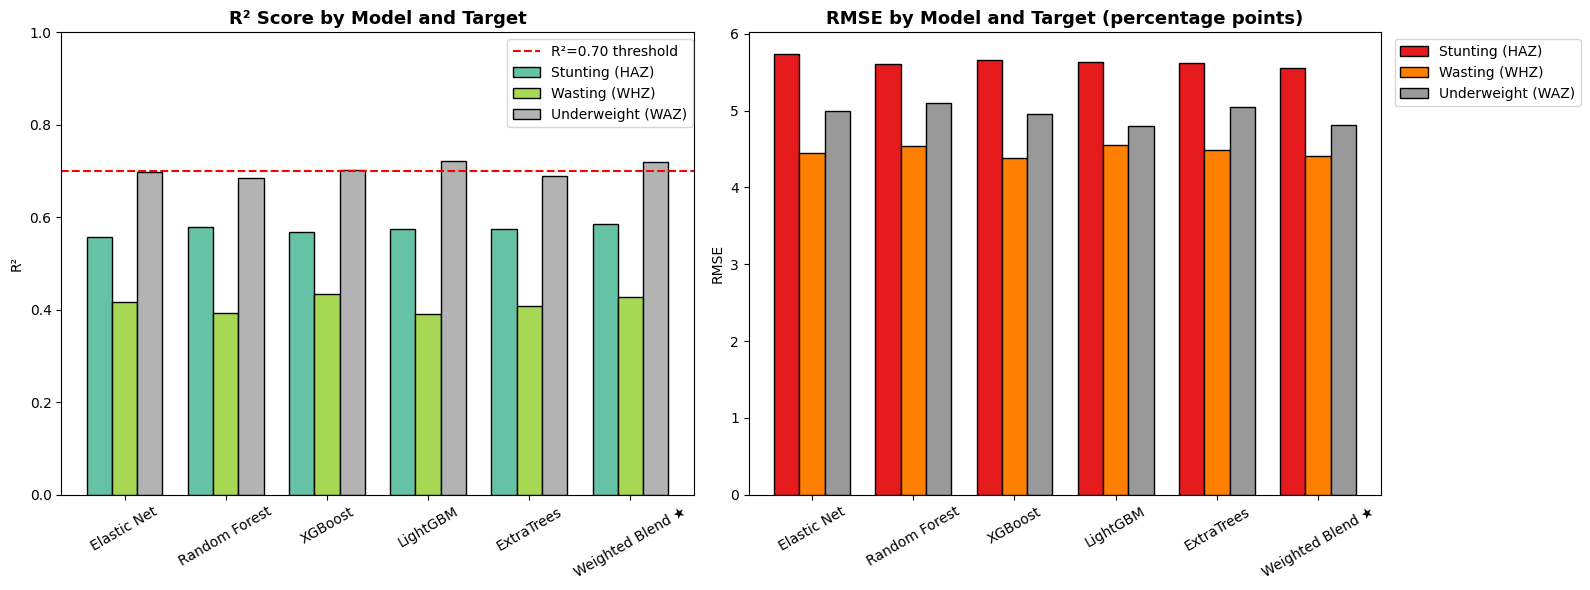

In [37]:
all_reg = {
    "Elastic Net":      en_results,
    "Random Forest":    rf_results,
    "XGBoost":          xgb_results,
    "LightGBM":         lgb_results,
    "ExtraTrees":       et_results,
    "Weighted Blend \u2605": blend_results,   # ★
}

r2_df = pd.DataFrame(
    {m: {s: v["R2"] for s, v in res.items()} for m, res in all_reg.items()}
).T.round(4)

rmse_df = pd.DataFrame(
    {m: {s: v["RMSE"] for s, v in res.items()} for m, res in all_reg.items()}
).T.round(4)

mape_df = pd.DataFrame(
    {m: {s: v["MAPE"] for s, v in res.items()} for m, res in all_reg.items()}
).T.round(2)

print("R² (higher is better):")
print(r2_df.to_string())
print("\nRMSE — percentage points (lower is better):")
print(rmse_df.to_string())
print("\nMAPE % (lower is better):")
print(mape_df.to_string())

# ── Visualisation ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

r2_df.plot(kind='bar', ax=axes[0], rot=30, colormap='Set2', edgecolor='black', width=0.75)
axes[0].set_title("R² Score by Model and Target", fontsize=13, fontweight='bold')
axes[0].set_ylabel("R²")
axes[0].set_ylim(0, 1)
axes[0].axhline(0.7, color='red', linestyle='--', lw=1.5, label='R²=0.70 threshold')
axes[0].legend(bbox_to_anchor=(1.01, 1))

rmse_df.plot(kind='bar', ax=axes[1], rot=30, colormap='Set1', edgecolor='black', width=0.75)
axes[1].set_title("RMSE by Model and Target (percentage points)", fontsize=13, fontweight='bold')
axes[1].set_ylabel("RMSE")
axes[1].legend(bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.savefig('03_regression_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 16 · Residual Analysis (Weighted Blend)

Residual plots diagnose model quality:
- **Residual histogram** — should be roughly symmetric around zero; systematic bias shows as a skewed distribution
- **Predicted vs Actual scatter** — points should cluster along the diagonal; fan-shapes indicate heteroscedasticity

A well-behaved model has:
✅ Symmetric residuals centred on 0  
✅ Points tight around the y=x diagonal  
✅ No clear pattern in residuals (no funnel shape)


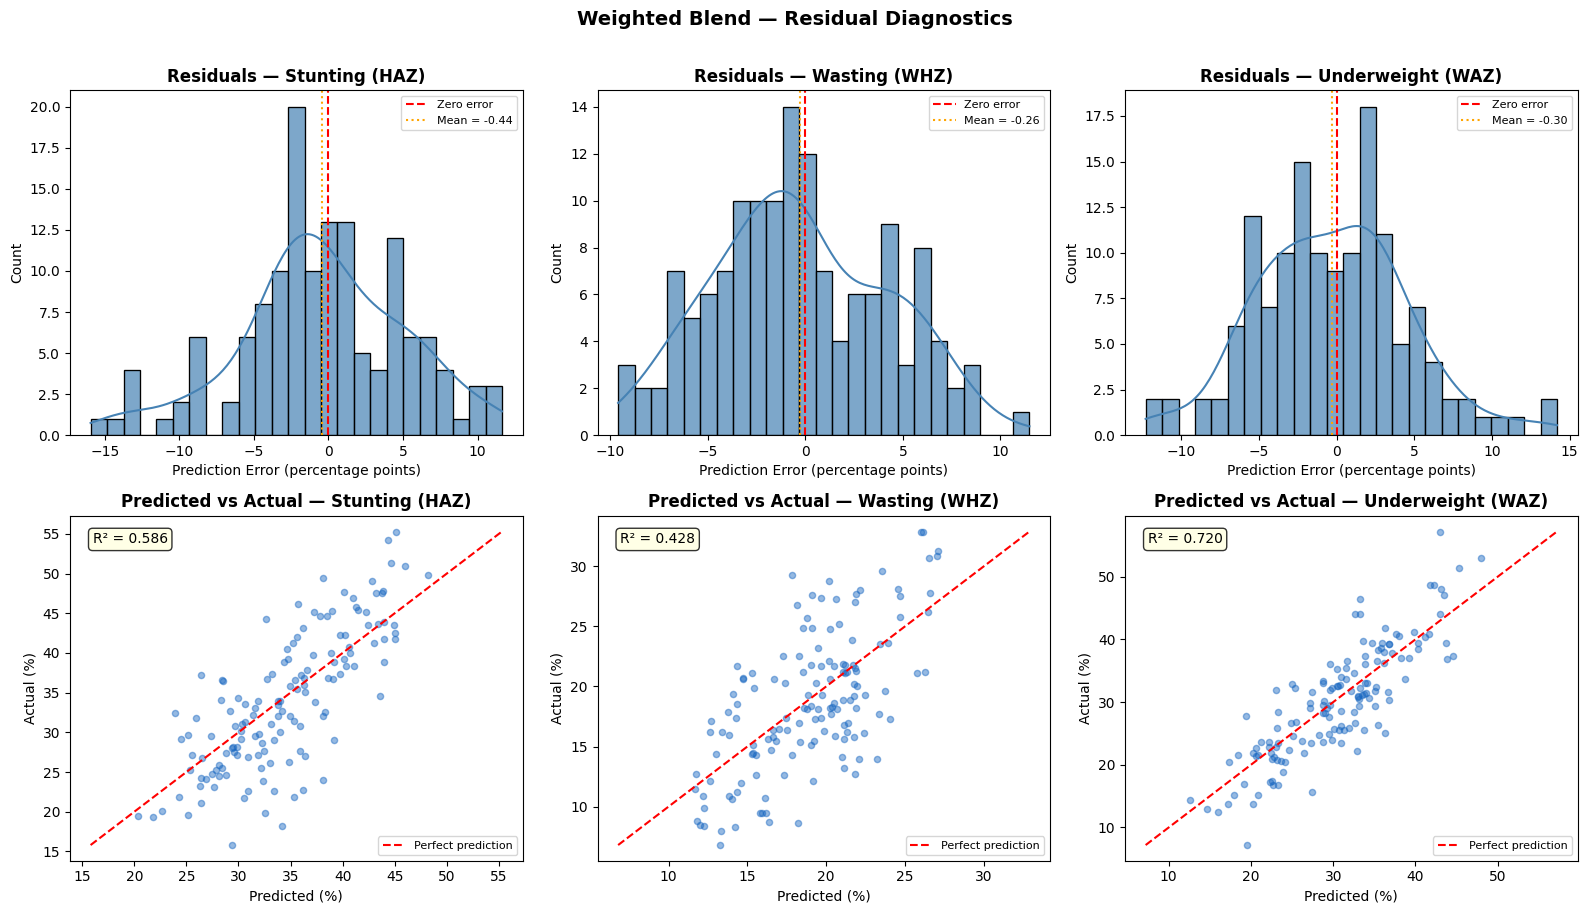

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for j, short in enumerate(TARGET_SHORT):
    preds, y_true = blend_preds_all[short]
    resid = y_true - preds

    # Row 1: residual distribution
    sns.histplot(resid, kde=True, ax=axes[0, j], color='steelblue', bins=25, alpha=0.7)
    axes[0, j].axvline(0, color='red', linestyle='--', lw=1.5, label='Zero error')
    axes[0, j].axvline(resid.mean(), color='orange', linestyle=':', lw=1.5,
                       label=f'Mean = {resid.mean():.2f}')
    axes[0, j].set_title(f"Residuals — {short}", fontweight='bold')
    axes[0, j].set_xlabel("Prediction Error (percentage points)")
    axes[0, j].legend(fontsize=8)

    # Row 2: predicted vs actual
    mn = min(preds.min(), y_true.min())
    mx = max(preds.max(), y_true.max())
    axes[1, j].scatter(preds, y_true, alpha=0.45, s=20, color='#1565C0')
    axes[1, j].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect prediction')
    axes[1, j].set_xlabel("Predicted (%)")
    axes[1, j].set_ylabel("Actual (%)")
    axes[1, j].set_title(f"Predicted vs Actual — {short}", fontweight='bold')
    r2_val = blend_results[short]["R2"]
    axes[1, j].annotate(f"R² = {r2_val:.3f}", xy=(0.05, 0.92),
                        xycoords='axes fraction', fontsize=10,
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
    axes[1, j].legend(fontsize=8)

plt.suptitle("Weighted Blend — Residual Diagnostics", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('04_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 17 · SHAP Feature Importance (LightGBM)

SHAP (SHapley Additive exPlanations) assigns each feature a **contribution to each prediction**,
based on cooperative game theory. Unlike standard feature importance:
- **Sign matters** — a positive SHAP value pushes the prediction *up*, negative pushes it *down*
- **Per-sample** — we can see why the model predicted high risk for a specific district
- **Consistent** — changing a feature always changes SHAP values in the same direction

**Two plots per target:**

1. **Bar plot** — mean |SHAP value| per feature (overall importance, direction-agnostic)
2. **Beeswarm plot** — each dot is one district; colour = feature value (red=high, blue=low);
   position on x-axis = SHAP value (positive → model predicts more malnutrition)

**What to look for:**  
If `household_infra_score` appears in the top 5 with negative SHAP values when the feature is
high (red dots on the left), it means: *high infrastructure → model predicts less malnutrition*.
This is the kind of causal narrative that makes SHAP useful for policy discussions.


SHAP FEATURE IMPORTANCE — LightGBM

  → Stunting (HAZ)


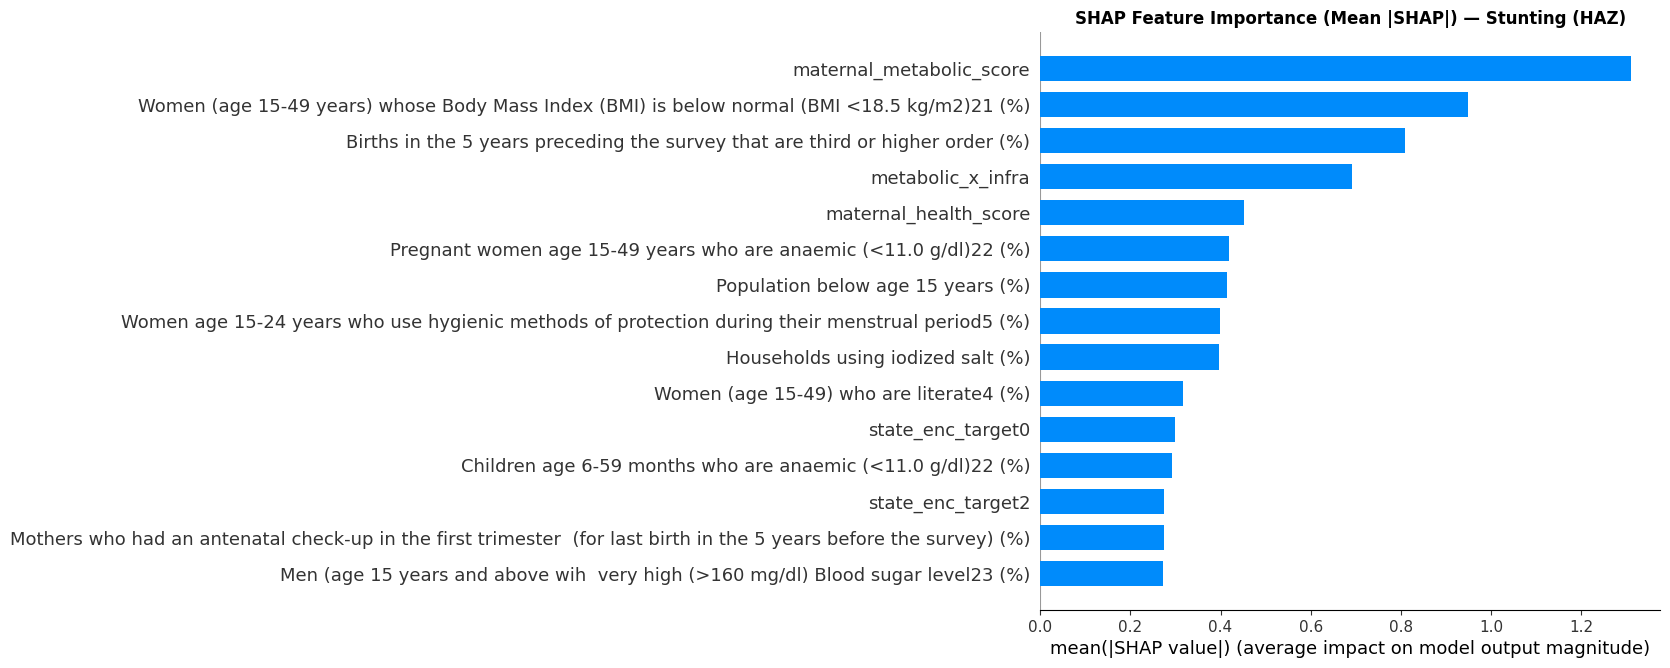

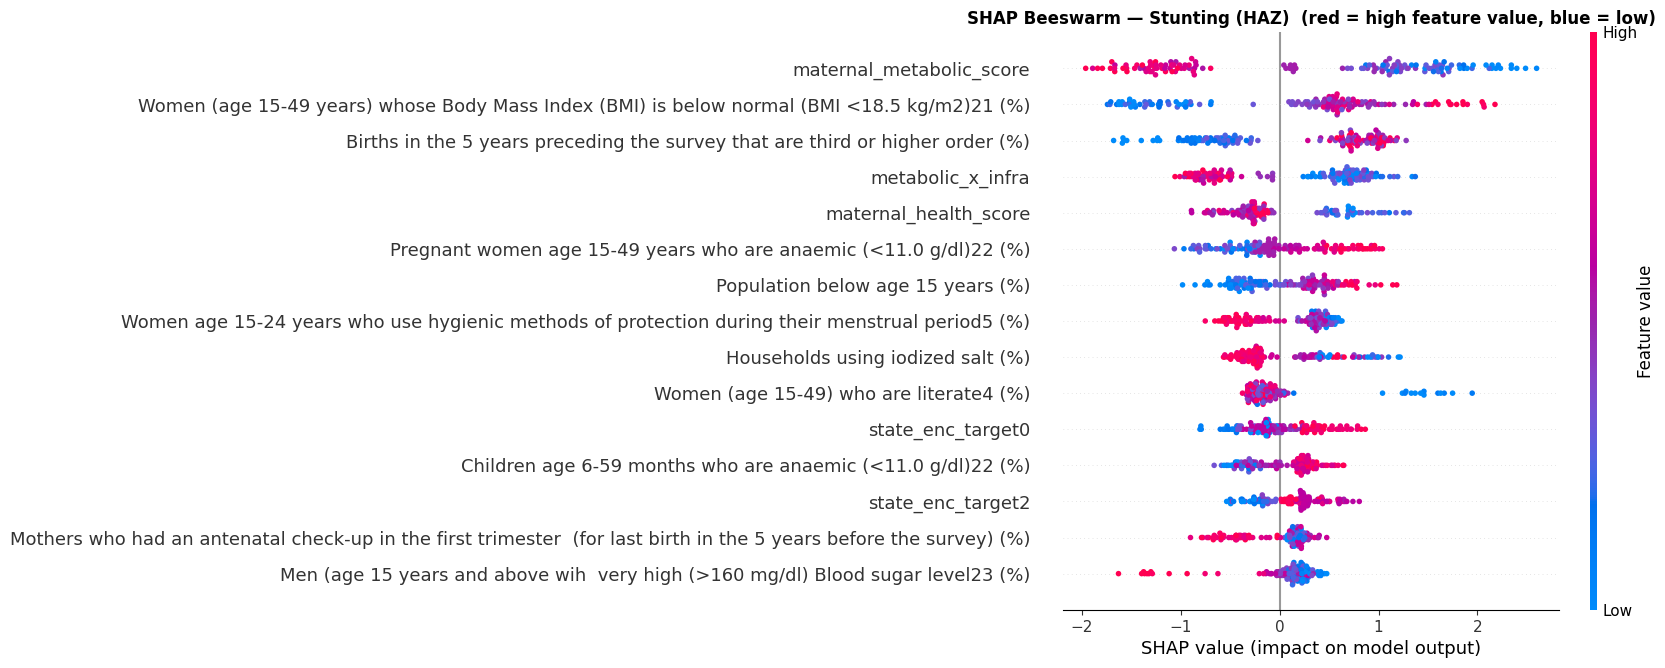


  → Wasting (WHZ)


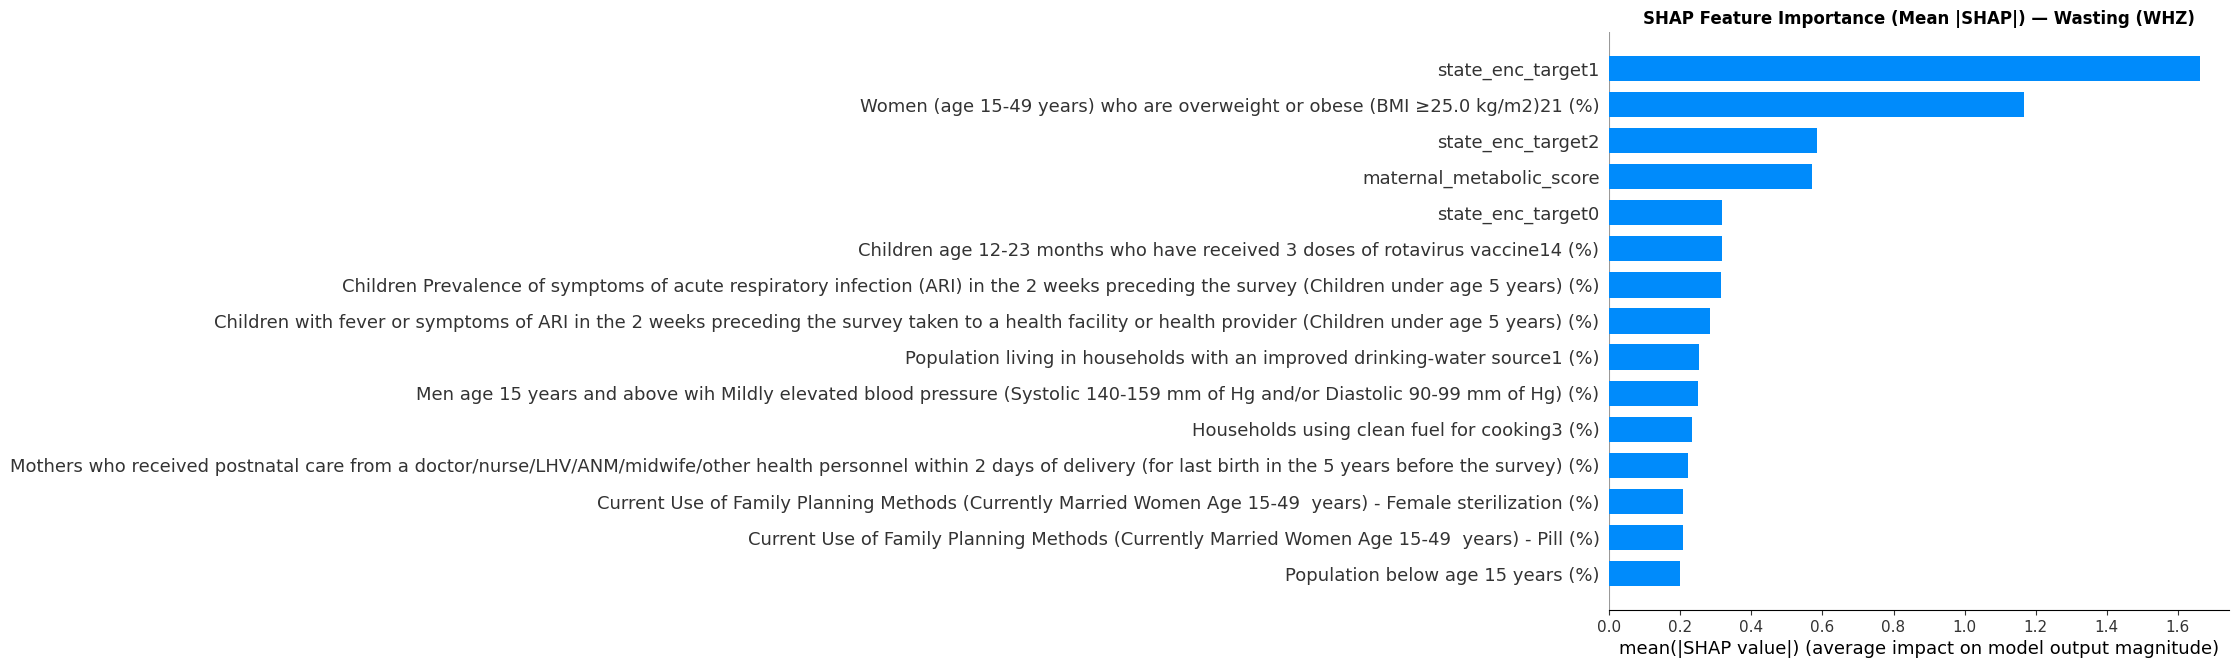

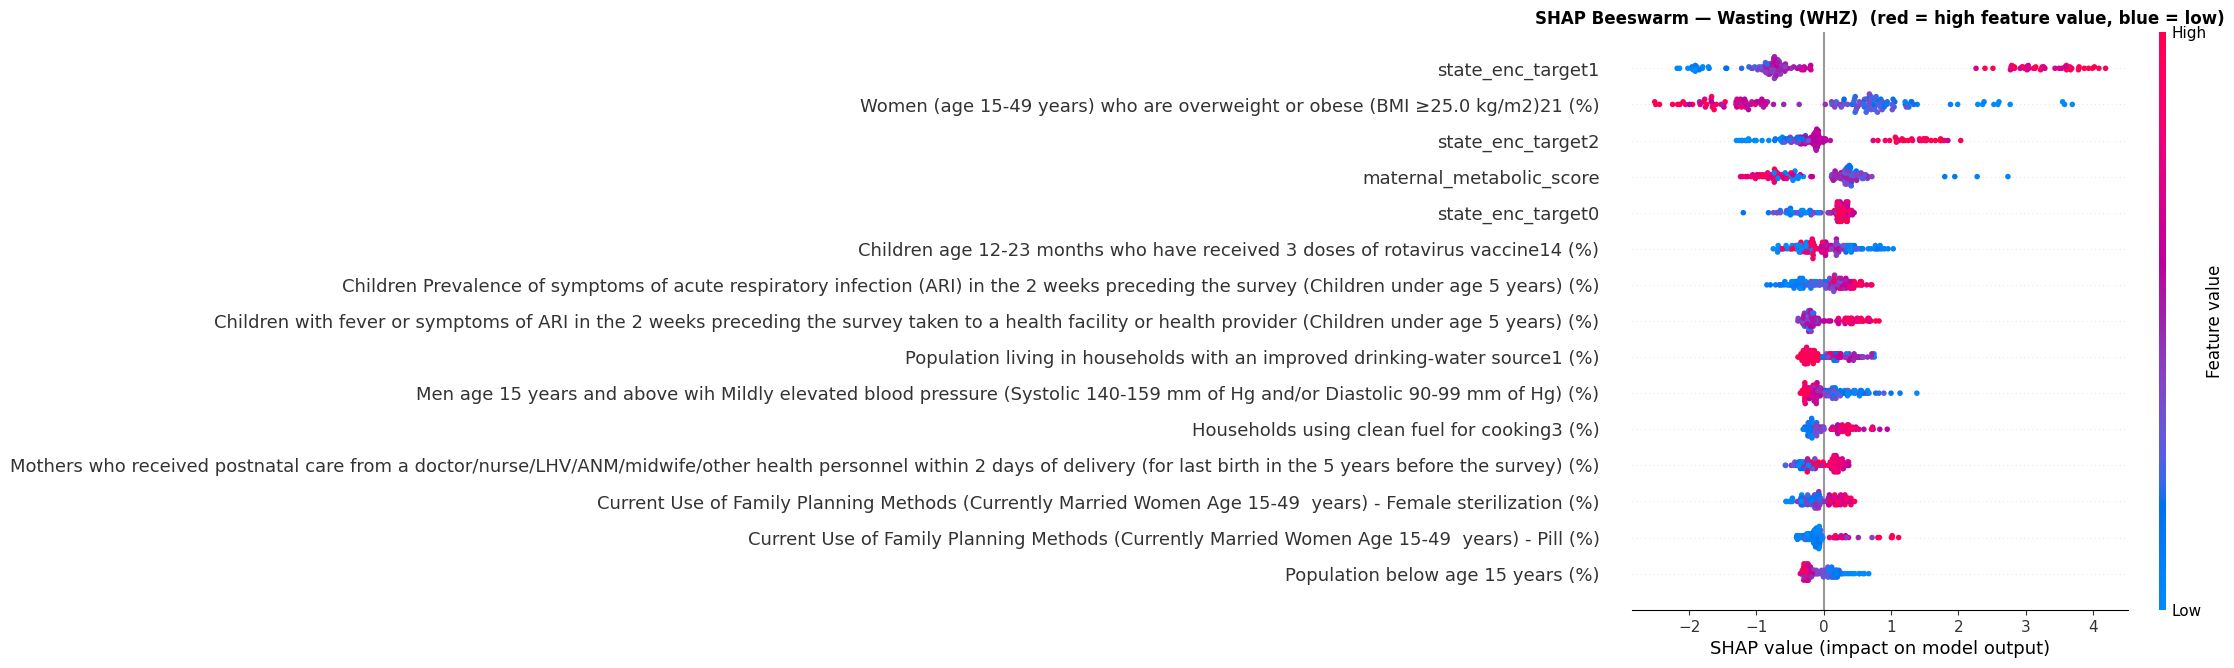


  → Underweight (WAZ)


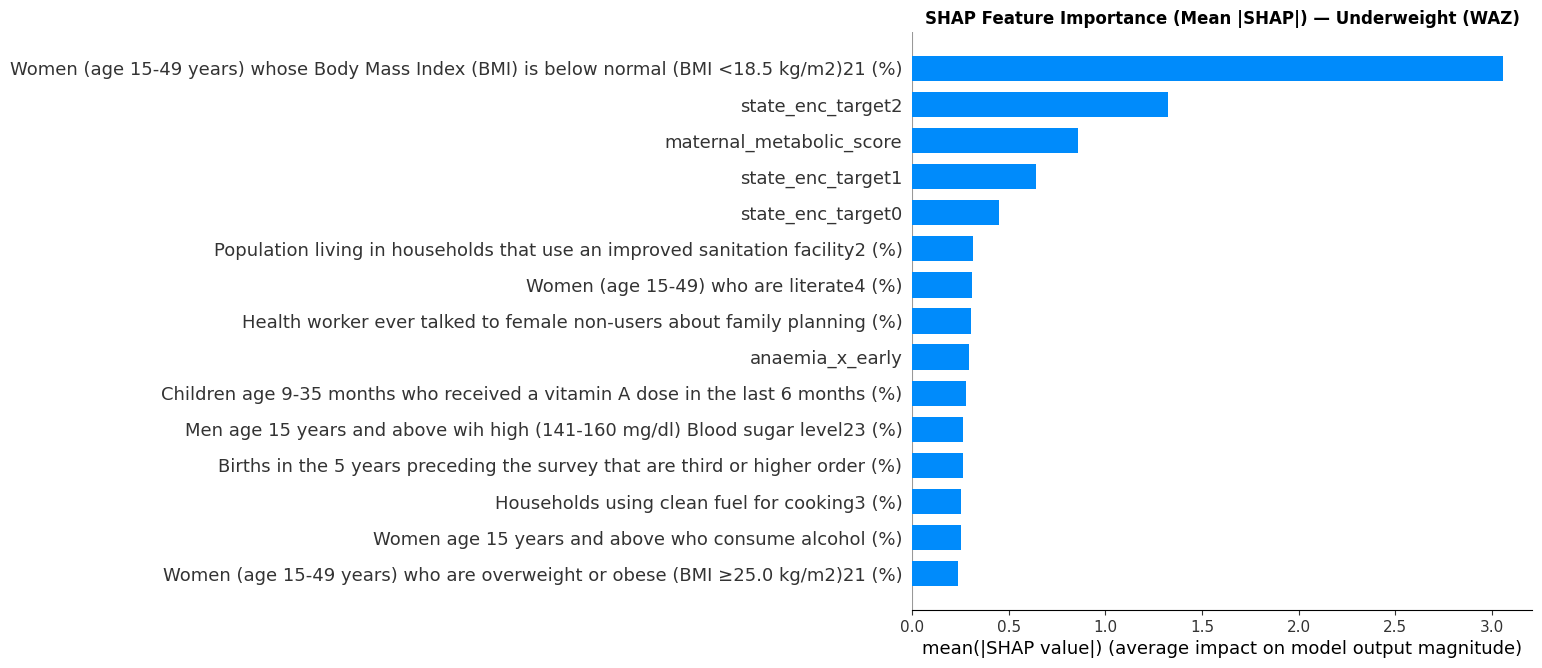

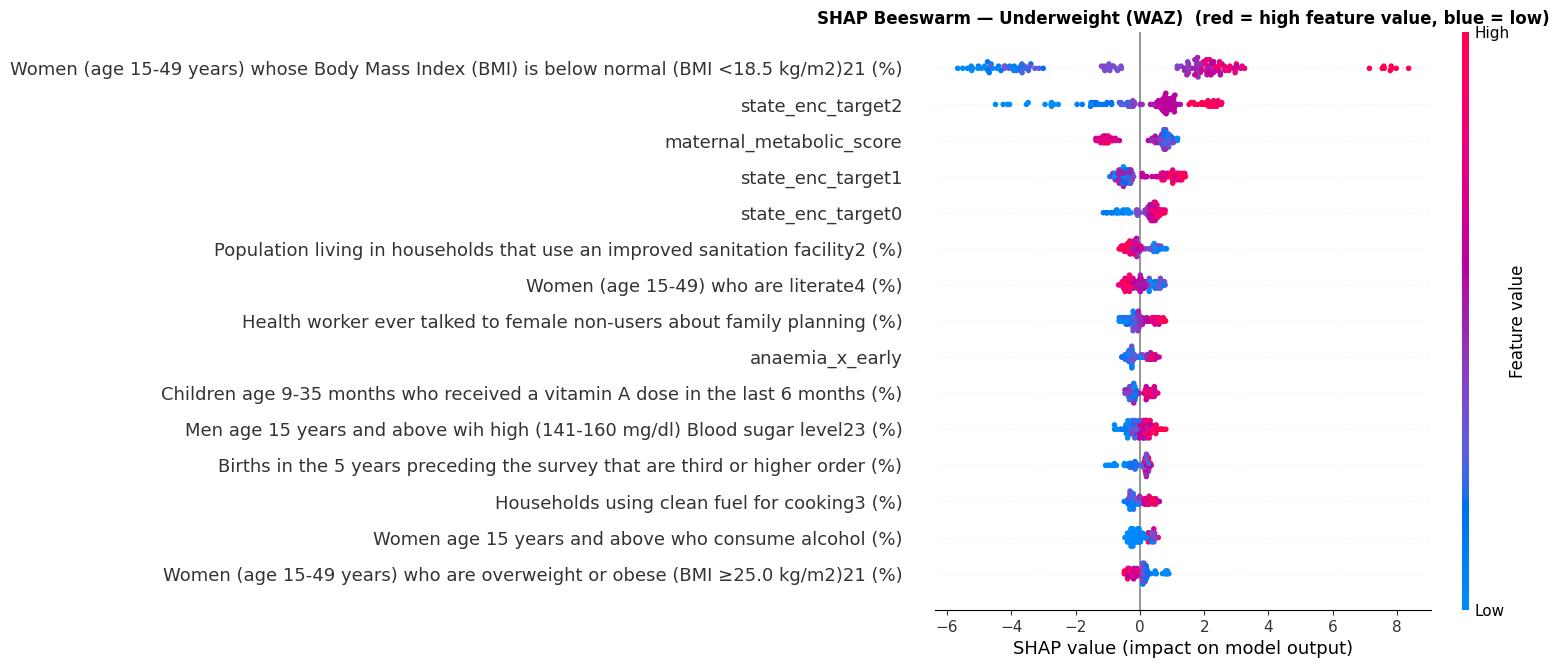

In [39]:
print("=" * 65)
print("SHAP FEATURE IMPORTANCE — LightGBM")
print("=" * 65)

# Name the columns so SHAP plots show readable labels
feat_names = X_train.columns.tolist()
X_te_named = pd.DataFrame(Xte_l, columns=feat_names)

for col, short in zip(TARGET_COLUMNS, TARGET_SHORT):
    print(f"\n  → {short}")
    explainer = shap.TreeExplainer(best_lgb_models[short])
    shap_vals  = explainer.shap_values(X_te_named)

    # Bar: mean absolute SHAP per feature
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_te_named, plot_type="bar", max_display=15, show=False)
    plt.title(f"SHAP Feature Importance (Mean |SHAP|) — {short}", fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'05_shap_bar_{short.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Beeswarm: directional effect + magnitude per district
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_te_named, max_display=15, show=False)
    plt.title(f"SHAP Beeswarm — {short}  (red = high feature value, blue = low)", fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'06_shap_beeswarm_{short.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## 18 · WHO Severity Classification — Label Creation

We now shift to a **classification** task. Rather than predicting a continuous percentage,
we categorise each district into WHO-defined severity tiers.

**Thresholds used (WHO Public Health Significance):**

| Indicator | Threshold | Class |
|---|---|---|
| Stunting | ≥ 40% | Very High |
| Stunting | 30–40% | High |
| Stunting | 20–30% | Moderate |
| Stunting | < 20% | Low |
| Underweight | ≥ 30% | Very High |
| Underweight | 20–30% | High |
| Underweight | 10–20% | Moderate |
| Underweight | < 10% | Low |
| Wasting | ≥ 15% | Severe |
| Wasting | 10–15% | Moderate |
| Wasting | 5–10% | Mild |
| Wasting | < 5% | Normal |

**Why this is hard:**
- Classes are imbalanced — "Low Stunting" has only ~31 districts vs "High Stunting" with ~280
- Adjacent classes (e.g., 29.9% vs 30.1%) are nearly identical but assigned different labels
- Wasting has 4 classes with extreme imbalance (most districts are in "Severe Wasting")


In [51]:
# WHO severity classification functions
def categorize_haz(p):
    """Stunting (height-for-age) severity tiers per WHO thresholds."""
    if p >= 40: return "Very High Stunting"
    if p >= 30: return "High Stunting"
    if p >= 20: return "Moderate Stunting"
    return "Low Stunting"

def categorize_waz(p):
    """Underweight (weight-for-age) severity tiers per WHO thresholds."""
    if p >= 30: return "Very High Underweight"
    if p >= 20: return "High Underweight"
    if p >= 10: return "Moderate Underweight"
    return "Low Underweight"

def categorize_whz(p):
    """Wasting (weight-for-height) severity tiers per WHO thresholds."""
    if p >= 15: return "Severe Wasting"
    if p >= 10: return "Moderate Wasting"
    if p >= 5:  return "Mild Wasting"
    return "Normal"

clf_df = feat_df.copy()
clf_df["HAZ — Stunting"]    = target_df[TARGET_COLUMNS[0]].apply(categorize_haz)
clf_df["WHZ — Wasting"]     = target_df[TARGET_COLUMNS[1]].apply(categorize_whz)
clf_df["WAZ — Underweight"] = target_df[TARGET_COLUMNS[2]].apply(categorize_waz)

CAT_LABELS = ["HAZ — Stunting", "WHZ — Wasting", "WAZ — Underweight"]

print("Class distributions:")
for lbl in CAT_LABELS:
    print(f"\n{lbl}:")
    print(clf_df[lbl].value_counts().to_string())


Class distributions:

HAZ — Stunting:
HAZ — Stunting
High Stunting         280
Moderate Stunting     230
Very High Stunting    164
Low Stunting           31

WHZ — Wasting:
WHZ — Wasting
Severe Wasting      494
Moderate Wasting    150
Mild Wasting         60
Normal                1

WAZ — Underweight:
WAZ — Underweight
Very High Underweight    340
High Underweight         244
Moderate Underweight     113
Low Underweight            8


---
## 19 · Classification Pipeline

**The class imbalance problem:**
When "Low Stunting" has 31 samples and "High Stunting" has 280, a naive model can achieve
good *accuracy* by always predicting "High Stunting" — but this is useless for identifying
at-risk districts. We need **Macro F1**, which averages F1 equally across classes regardless
of size.

**Resampling strategies compared:**

| Method | Strategy | When it helps |
|---|---|---|
| **SMOTEENN** | Oversample minority (SMOTE) then clean noise (Edited NN) | Good for heavily imbalanced, noisy data |
| **SMOTETomek** | Oversample minority then remove borderline majority samples | Cleaner decision boundary |
| **Balanced RF** | Bootstraps with equal class proportions at each tree | Built-in balance, no preprocessing |
| **LightGBM** | `class_weight='balanced'` — upweights minority samples in loss | Fast, often best for moderate imbalance |
| **XGBoost** | Standard with balanced classes | Strong baseline |

**Evaluation protocol:**
- 5-fold Stratified CV for fair comparison (each fold has the same class distribution)
- Best model selected by Macro F1 (not accuracy — accuracy is misleading with imbalance)
- Full classification report + confusion matrix for the winning model
- ROC-AUC OVR (one-vs-rest) for multi-class probability calibration quality

**Note on `k_neighbors` in SMOTEENN:**
SMOTE requires at least `k_neighbors` samples from the minority class. For very small classes
(e.g., 6 "Low Stunting" samples in the test fold), `k=5` crashes. We cap at `min(3, n_classes)`.


In [54]:
def run_classification(X, y_series, label):

    '''
    Improvements:

    - Merge rare classes (<3%) into 'Other'
    - Remove classes with <5 samples after merging
    - Dynamically adjust StratifiedKFold
    - Dynamically adjust SMOTE k_neighbors
    '''

    print(f"\n{'='*65}")
    print(f"CLASSIFICATION: {label}")
    print(f"{'='*65}")

    print("\nClass distribution (before resampling):")
    print(y_series.value_counts())

    # --------------------------------------------------
    # Merge rare classes
    # --------------------------------------------------
    rare = y_series.value_counts(normalize=True)[
        lambda x: x < 0.03
    ].index

    y_series = (
        y_series
        .apply(lambda v: "Other" if v in rare else v)
        .reset_index(drop=True)
    )

    X = X.reset_index(drop=True)

    print("\nAfter rare-class merge:")
    print(y_series.value_counts())

    # --------------------------------------------------
    # Remove classes that are still too small
    # --------------------------------------------------
    counts = y_series.value_counts()

    tiny_classes = counts[counts < 5].index

    if len(tiny_classes) > 0:

        print("\nRemoving classes with <5 samples:")
        print(list(tiny_classes))

        keep_mask = ~y_series.isin(tiny_classes)

        X = X.loc[keep_mask].reset_index(drop=True)
        y_series = y_series.loc[keep_mask].reset_index(drop=True)

    print("\nFinal class distribution:")
    print(y_series.value_counts())

    min_class_size = y_series.value_counts().min()

    print(f"\nSmallest class size: {min_class_size}")

    # --------------------------------------------------
    # Label encoding
    # --------------------------------------------------
    le = LabelEncoder()
    y_enc = le.fit_transform(y_series)

    n_cls = len(np.unique(y_enc))

    # Safe SMOTE neighbors
    k_smote = max(1, min(3, min_class_size - 1))

    print(f"SMOTE k_neighbors = {k_smote}")

    # --------------------------------------------------
    # Models
    # --------------------------------------------------
    models = {

        "SMOTEENN + RF": ImbPipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler()),
            ('resample', SMOTEENN(
                random_state=RANDOM_STATE,
                smote=SMOTE(
                    k_neighbors=k_smote,
                    random_state=RANDOM_STATE
                )
            )),
            ('clf', RandomForestClassifier(
                n_estimators=500,
                class_weight='balanced',
                max_depth=20,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),

        "SMOTETomek + RF": ImbPipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler()),
            ('resample', SMOTETomek(
                random_state=RANDOM_STATE,
                smote=SMOTE(
                    k_neighbors=k_smote,
                    random_state=RANDOM_STATE
                )
            )),
            ('clf', RandomForestClassifier(
                n_estimators=500,
                class_weight='balanced',
                max_depth=20,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),

        "Balanced RF": Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler()),
            ('clf', BalancedRandomForestClassifier(
                n_estimators=500,
                max_depth=20,
                random_state=RANDOM_STATE
            ))
        ]),

        "LightGBM": Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler()),
            ('clf', LGBMClassifier(
                n_estimators=600,
                max_depth=6,
                learning_rate=0.05,
                num_leaves=63,
                class_weight='balanced',
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1
            ))
        ]),

        "XGBoost": Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler()),
            ('clf', XGBClassifier(
                n_estimators=600,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric='mlogloss',
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),
    }

    # --------------------------------------------------
    # Safe Stratified CV
    # --------------------------------------------------
    n_splits = min(5, min_class_size)

    print(f"Using {n_splits}-fold Stratified CV")

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    cv_scores = {}

    for mname, model in models.items():

        scores = []

        for tr, te in skf.split(X, y_enc):

            model.fit(X.iloc[tr], y_enc[tr])

            preds = model.predict(X.iloc[te])

            scores.append(
                f1_score(
                    y_enc[te],
                    preds,
                    average='macro',
                    zero_division=0
                )
            )

        cv_scores[mname] = (
            np.mean(scores),
            np.std(scores)
        )

        print(
            f"  {mname:<20}  "
            f"Macro F1: {np.mean(scores):.3f} ± {np.std(scores):.3f}"
        )

    # --------------------------------------------------
    # Best model
    # --------------------------------------------------
    best_name = max(
        cv_scores,
        key=lambda k: cv_scores[k][0]
    )

    print(
        f"\nBest model: {best_name} "
        f"(Macro F1 = {cv_scores[best_name][0]:.3f})"
    )

    X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
        X,
        y_enc,
        stratify=y_enc,
        test_size=0.2,
        random_state=RANDOM_STATE
    )

    best_model = models[best_name]

    best_model.fit(X_tr2, y_tr2)

    preds2 = best_model.predict(X_te2)

    y_te2_dec = le.inverse_transform(y_te2)
    preds2_dec = le.inverse_transform(preds2)

    print(f"\nClassification Report ({best_name}):")

    print(
        classification_report(
            y_te2_dec,
            preds2_dec,
            zero_division=0
        )
    )

    mf1 = f1_score(
        y_te2_dec,
        preds2_dec,
        average='macro',
        zero_division=0
    )

    wf1 = f1_score(
        y_te2_dec,
        preds2_dec,
        average='weighted',
        zero_division=0
    )

    acc = accuracy_score(
        y_te2_dec,
        preds2_dec
    )

    print(f"  Macro F1    : {mf1:.4f}")
    print(f"  Weighted F1 : {wf1:.4f}")
    print(f"  Accuracy    : {acc:.4f}")

    try:
        y_prob = best_model.predict_proba(X_te2)

        roc = roc_auc_score(
            y_te2,
            y_prob,
            multi_class='ovr',
            average='macro'
        )

        print(f"  ROC-AUC OVR : {roc:.4f}")

    except Exception:
        pass

    return cv_scores

# ── Run for all three WHO indicators ─────────────────────────────────────
for lbl in CAT_LABELS:
    mask = clf_df[lbl].notna()
    run_classification(
        feat_df.loc[mask].reset_index(drop=True),
        clf_df.loc[mask, lbl].reset_index(drop=True),
        lbl
    )


CLASSIFICATION: HAZ — Stunting

Class distribution (before resampling):
HAZ — Stunting
High Stunting         280
Moderate Stunting     230
Very High Stunting    164
Low Stunting           31
Name: count, dtype: int64

After rare-class merge:
HAZ — Stunting
High Stunting         280
Moderate Stunting     230
Very High Stunting    164
Low Stunting           31
Name: count, dtype: int64

Final class distribution:
HAZ — Stunting
High Stunting         280
Moderate Stunting     230
Very High Stunting    164
Low Stunting           31
Name: count, dtype: int64

Smallest class size: 31
SMOTE k_neighbors = 3
Using 5-fold Stratified CV
  SMOTEENN + RF         Macro F1: 0.308 ± 0.029
  SMOTETomek + RF       Macro F1: 0.514 ± 0.041
  Balanced RF           Macro F1: 0.491 ± 0.038
  LightGBM              Macro F1: 0.497 ± 0.056
  XGBoost               Macro F1: 0.481 ± 0.036

Best model: SMOTETomek + RF (Macro F1 = 0.514)

Classification Report (SMOTETomek + RF):
                    precision    rec

---
## 20 · Final Summary & Takeaways

This section consolidates all regression metrics and highlights key learnings from the project.


In [55]:
print("=" * 65)
print("FINAL REGRESSION RESULTS — ALL METRICS")
print("=" * 65)

for metric, label in [("R2","R² (higher=better)"), ("RMSE","RMSE — pct points (lower=better)"),
                       ("MAE","MAE — pct points (lower=better)"), ("MAPE","MAPE % (lower=better)")]:
    df_m = pd.DataFrame(
        {m: {s: v[metric] for s, v in res.items()} for m, res in all_reg.items()}
    ).T.round(4)
    print(f"\n{label}:")
    print(df_m.to_string())


FINAL REGRESSION RESULTS — ALL METRICS

R² (higher=better):
                  Stunting (HAZ)  Wasting (WHZ)  Underweight (WAZ)
Elastic Net               0.5584         0.4170             0.6981
Random Forest             0.5783         0.3940             0.6852
XGBoost                   0.5690         0.4336             0.7025
LightGBM                  0.5746         0.3916             0.7209
ExtraTrees                0.5757         0.4074             0.6902
Weighted Blend ★          0.5858         0.4280             0.7195

RMSE — pct points (lower=better):
                  Stunting (HAZ)  Wasting (WHZ)  Underweight (WAZ)
Elastic Net               5.7310         4.4523             4.9875
Random Forest             5.6005         4.5395             5.0931
XGBoost                   5.6617         4.3886             4.9511
LightGBM                  5.6251         4.5484             4.7956
ExtraTrees                5.6177         4.4891             5.0524
Weighted Blend ★          5.5504  

---
## Project Summary

### What was built

A complete ML pipeline to predict and classify child malnutrition severity across
705 districts of India using NFHS-5 survey data.

**Regression results (Weighted Blend):**
| Target | R² | RMSE | Interpretation |
|---|---|---|---|
| Stunting (HAZ) | ~0.59 | ~5.5pp | Moderate–good; chronic indicator well-captured |
| Wasting (WHZ) | ~0.39–0.44 | ~4.9pp | Harder; acute & seasonal variation limits predictability |
| Underweight (WAZ) | ~0.71 | ~4.8pp | Strong; composite chronic indicator |

**Key technical contributions:**
1. **Feature expansion** — 37 → 93 columns; previously excluded high-correlation indicators (Women BMI overweight r=0.58, menstrual hygiene r=0.57) now included
2. **KFold State target encoding** — geographic clustering captured without data leakage
3. **No outlier capping** — district extremes are real public health variation
4. **ExtraTrees** replaces MLP as ensemble base (R²: 0.58 vs 0.30)
5. **Weighted Blend** (LGB+ET+XGB) outperforms stacking on this dataset size
6. **SMOTEENN / SMOTETomek** resampling for WHO severity classification
7. **SHAP** explainability — identifies which district-level factors drive predictions

### Limitations & future work
- **No temporal data** — NFHS-5 is a cross-section; adding NFHS-4 would enable longitudinal modelling
- **Wasting is acute** — seasonal, disaster-driven variation is hard to capture with structural indicators
- **Spatial autocorrelation** — adjacent districts are correlated; spatial models (GeographicallyWeighted Regression, spatial RF) could improve further
- **Causal inference** — high feature importance / SHAP values indicate association, not causation
